In [1]:
!unset LD_LIBRARY_PATH

In [2]:
!echo $LD_LIBRARY_PATH

In [3]:
# %load_ext autoreload
# %autoreload 2

import os

from functools import partial

if "KERAS_BACKEND" not in os.environ:
    os.environ["KERAS_BACKEND"] = "jax"

import arviz as az
import blackjax
import bayesflow as bf
import jax
import jax.numpy as jnp
import keras
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from data import load_hdf5, save_hdf5
from mcmc import model_nle, warmup
from plots import create_profile_likelihood_plot
from priors import truncated_normal_rvs
from rdmc import rdmc_experiment_simple

INFO:2025-11-14 17:37:41,670:jax._src.xla_bridge:822: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:bayesflow:Using backend 'jax'


In [4]:
def prior_fun_train(
    drift_c_intercept_loc=0.05,
    drift_c_intercept_scale=0.05,
    drift_c_slope_loc=0.5,
    drift_c_slope_scale=0.1,
    amp_shape=10,
    amp_scale=2,
    tau_shape=8,
    tau_scale=10,
    sd_true_shape=80,
    sd_true_scale=0.05,
    threshold_shape=100,
    threshold_scale=0.7,
    t0_loc=300,
    t0_scale=200,
    rng=np.random.default_rng(2025),
):
    drift_c_intercept = truncated_normal_rvs(drift_c_intercept_loc, drift_c_intercept_scale, random_state=rng)
    drift_c_slope = truncated_normal_rvs(drift_c_slope_loc, drift_c_slope_scale, random_state=rng)
    amp = rng.gamma(shape=amp_shape, scale=amp_scale)
    tau = rng.gamma(shape=tau_shape, scale=tau_scale)
    s_true = rng.gamma(shape=sd_true_shape, scale=sd_true_scale)
    b = rng.gamma(shape=threshold_shape, scale=threshold_scale)
    t0 = truncated_normal_rvs(t0_loc, t0_scale, random_state=rng)

    return {
        "v_c_intercept": drift_c_intercept,
        "v_c_slope": drift_c_slope,
        "amp": amp,
        "tau": tau,
        "s_true": s_true,
        "b": b,
        "t0": t0
    }

In [5]:
def simulator_fun(**kwargs):
    return rdmc_experiment_simple(**kwargs, t_max=2000, seed=2025, a_shape=2, s_false=4)


def meta(batch_size):
    num_obs = np.random.default_rng(2025).integers(250, 500)

    return dict(num_obs=num_obs)

simulator = bf.simulators.make_simulator([prior_fun_train, simulator_fun], meta_fn=meta)

In [6]:
param_names = ["v_c_intercept", "v_c_slope", "tau", "amp", "s_true", "b", "t0"]

In [7]:
approximator = keras.saving.load_model("checkpoints/rdmc_nle_spline_shallow_20.keras")

In [8]:
test_data = simulator.sample(1)
# save_hdf5("test_data.hdf5", test_data)
# test_data = load_hdf5("test_data.hdf5")

In [ ]:
prior_draws = np.array([test_data[p] for p in param_names]).squeeze()

approximator.log_prob(test_data).sum()


1710.4823

In [10]:
prior_draws

array([1.79993712e-01, 4.69979375e-01, 2.69825543e+01, 1.61718161e+01,
       3.65381787e+00, 7.47867517e+01, 2.64891122e+02])

In [11]:
model_nle(test_data, approximator, fixed=None)(jnp.log(prior_draws))

Array(1710.5073, dtype=float32)

In [12]:
ll_fun = model_nle(test_data, approximator)

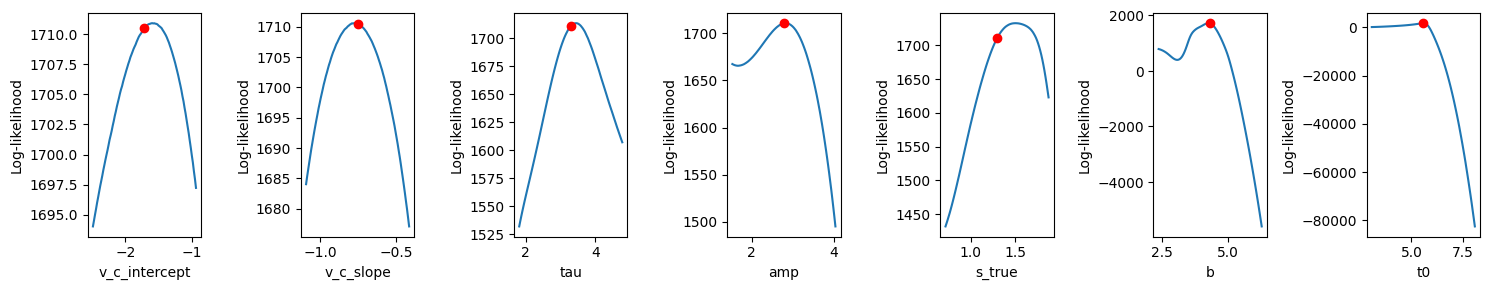

In [14]:
_ = create_profile_likelihood_plot(ll_fun, jnp.log(prior_draws), param_names)

In [15]:
rng_key = jax.random.key(2025)

In [16]:
inv_mass_matrix = jnp.eye(len(param_names)) * 1e-4  # 5x5 for five parameters
# inv_mass_matrix = jnp.array([7.73e-05, 4.44e-04, 2.36e+02, 2.42e+01,
        # 2.25e-01, 2.06e+01, 5.65e+00])
n_samples = 100

In [17]:
def smc_inference_loop(rng_key, smc_kernel, initial_state, max_steps=1000):
    """Run the tempered SMC algorithm and retain all intermediate states.

    Returns (n_iter, final_state, history) where `history` is a PyTree
    with arrays shaped (max_steps+1, ...) storing the state at each iteration index.
    """
    def cond(carry):
        i, state, _k, _hist = carry
        return state.lmbda < 1

    # initialize history PyTree with an extra leading axis for time
    def init_history(state):
        def make_buffer(x):
            shp = (max_steps + 1,) + tuple(jnp.shape(x))
            return jnp.zeros(shp, dtype=jnp.asarray(x).dtype)
        return jax.tree.map(make_buffer, state)

    history0 = init_history(initial_state)
    history0 = jax.tree.map(lambda h, x: h.at[0].set(x), history0, initial_state)

    @jax.jit
    def one_step(carry):
        i, state, k, history = carry
        k, subk = jax.random.split(k, 2)
        next_state, _ = smc_kernel(subk, state)
        # store the new state at index i+1
        history = jax.tree.map(lambda h, x: h.at[i + 1].set(x), history, next_state)
        return i + 1, next_state, k, history

    carry0 = (0, initial_state, rng_key, history0)
    n_iter, final_state, _k, final_history = jax.lax.while_loop(cond, one_step, carry0)

    return n_iter, final_state, final_history

In [18]:
def prior_log_prob(x):
    # x shape: (..., 7)
    x = jnp.exp(x)
    v_c_intercept_lp = jax.scipy.stats.norm.logpdf(x[..., 0], loc=0.05, scale=0.05)
    v_c_slope_lp     = jax.scipy.stats.norm.logpdf(x[..., 1], loc=0.5, scale=0.1)
    tau_lp           = jax.scipy.stats.gamma.logpdf(x[..., 2], a=8, scale=10)
    amp_lp           = jax.scipy.stats.gamma.logpdf(x[..., 3], a=10, scale=2)
    s_true_lp        = jax.scipy.stats.gamma.logpdf(x[..., 4], a=80, scale=0.05)
    b_lp             = jax.scipy.stats.gamma.logpdf(x[..., 5], a=100, scale=0.7)
    t0_lp            = jax.scipy.stats.norm.logpdf(x[..., 6], loc=300, scale=200)
    return (
        v_c_intercept_lp
        + v_c_slope_lp
        + tau_lp
        + amp_lp
        + s_true_lp
        + b_lp
        + t0_lp
    )

In [19]:
def sample_prior_particles(n_samples, seed=2025):
    rng = np.random.default_rng(seed)
    v_c_intercept = truncated_normal_rvs(loc=0.05, scale=0.05, size=n_samples, random_state=rng)
    v_c_slope     = truncated_normal_rvs(loc=0.5, scale=0.1, size=n_samples, random_state=rng)
    tau           = rng.gamma(shape=8, scale=10, size=n_samples)
    amp           = rng.gamma(shape=10, scale=2, size=n_samples)
    s_true        = rng.gamma(shape=80, scale=0.05, size=n_samples)
    b             = rng.gamma(shape=100, scale=0.7, size=n_samples)
    t0            = truncated_normal_rvs(loc=300, scale=50, size=n_samples, random_state=rng)
    # Stack in the order of param_names
    return np.log(np.stack([v_c_intercept, v_c_slope, tau, amp, s_true, b, t0], axis=-1))

In [20]:
kernel_fun = blackjax.hmc

In [ ]:
rng_key = jax.random.key(2025)
    
rng_key, warmup_key = jax.random.split(rng_key)

init_position = sample_prior_particles(1, seed=2025)

kernel, last_state, warmup_parameters = warmup(
    kernel_fun,
    ll_fun,
    init_position,
    500,
    warmup_key,
    # target_acceptance_rate=0.9,
    progress_bar=True,
    num_integration_steps=100
)

2025-11-14 17:39:05.306146: W external/xla/xla/hlo/transforms/simplifiers/hlo_rematerialization.cc:3183] Can't reduce memory use below 927.75MiB (972821420 bytes) by rematerialization; only reduced to 6.30GiB (6765956224 bytes), down from 6.30GiB (6766070216 bytes) originally


Running window adaptation


In [22]:
prior_draws

array([1.79993712e-01, 4.69979375e-01, 2.69825543e+01, 1.61718161e+01,
       3.65381787e+00, 7.47867517e+01, 2.64891122e+02])

In [23]:
np.exp(last_state.position)

array([[  0.18332121,   0.5902625 ,  62.84017   ,   8.039797  ,
          3.8762703 ,  67.981384  , 132.87085   ]], dtype=float32)

In [24]:
warmup_parameters

{'step_size': Array(0.00025125, dtype=float32, weak_type=True),
 'inverse_mass_matrix': Array([2.4400857e-05, 2.4469282e-05, 2.4412420e-05, 2.4428007e-05,
        2.4394754e-05, 2.4427556e-05, 2.4479172e-05], dtype=float32),
 'num_integration_steps': 100}

In [ ]:
import blackjax.smc.resampling as resampling
from blackjax.smc import extend_params

hmc_parameters = dict(
    step_size=1e-2, inverse_mass_matrix=inv_mass_matrix, num_integration_steps=100
)

tempered = blackjax.adaptive_tempered_smc(
    prior_log_prob,
    model_nle(test_data, approximator),
    kernel_fun.build_kernel(),
    kernel_fun.init,
    extend_params(warmup_parameters),
    resampling.systematic,
    0.5,
    num_mcmc_steps=1,
)

rng_key, init_key, sample_key = jax.random.split(rng_key, 3)
initial_smc_state = sample_prior_particles(n_samples, seed=2025)
initial_smc_state = tempered.init(initial_smc_state)

num_chains = 1

sample_keys = jax.random.split(sample_key, num_chains)

# initial_smc_states = tempered.init([sample_prior_particles(n_samples, i) for i in np.arange(num_chains)])

n_iter, smc_samples, smc_history = jax.vmap(smc_inference_loop, in_axes=(0, None, None))(sample_keys, tempered.step, initial_smc_state)
print("Number of steps in the adaptive algorithm: ", n_iter.item())

2025-11-14 17:27:20.215792: W external/xla/xla/tsl/framework/bfc_allocator.cc:501] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.67MiB (rounded to 2802944)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
2025-11-14 17:27:20.216097: W external/xla/xla/tsl/framework/bfc_allocator.cc:512] ****************************************************************************************************
E1114 17:27:20.216113  241419 pjrt_stream_executor_client.cc:3008] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 2802800 bytes. [tf-allocator-allocation-error='']


XlaRuntimeError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 2802800 bytes.

In [26]:
smc_history = jax.tree.map(lambda h: h[:, : n_iter[0] + 1], smc_history)

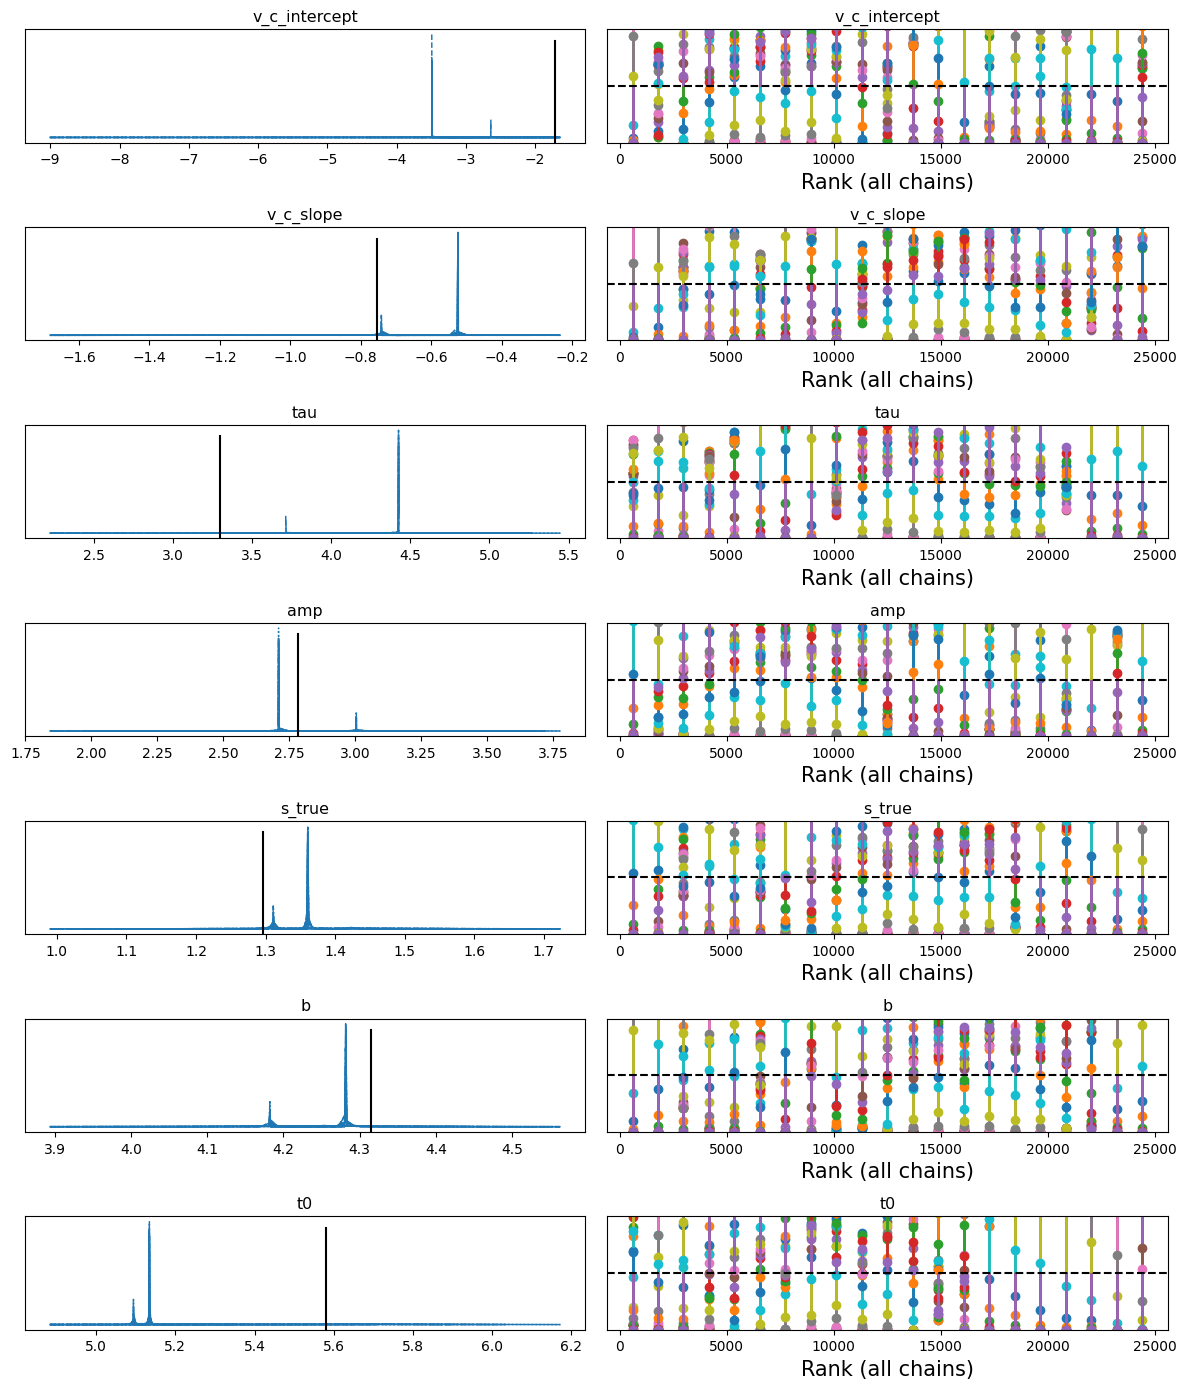

In [27]:
idata = az.from_dict(
    posterior={k: v
               for k, v in zip(param_names, np.moveaxis(smc_history.particles[0], (2, 0, 1), (0, 1, 2)))},)
ax = az.plot_trace(idata, compact=True, kind="rank_vlines")

for i, p in enumerate(np.log(prior_draws)):
    ax[i, 0].axvline(p, 0, 0.9, color="k")

plt.tight_layout()

In [28]:
for p1, p2, p3 in zip(smc_samples.particles.mean(axis=(0, 1)), initial_smc_state.particles.mean(axis=0), np.log(prior_draws)):
    print(p1, p2, p3)

-3.4911418 -3.0187164753574205 -1.7148333621697212
-0.5240874 -0.7049666972021654 -0.7550664687458677
4.425056 4.316493501886324 3.2951905215731934
2.7093189 2.9363699224111466 2.783269978960048
1.3604757 1.3867837042197206 1.2957726137947907
4.2815657 4.244449058274486 4.31464075340262
5.134276 5.684802706968712 5.579318880780447


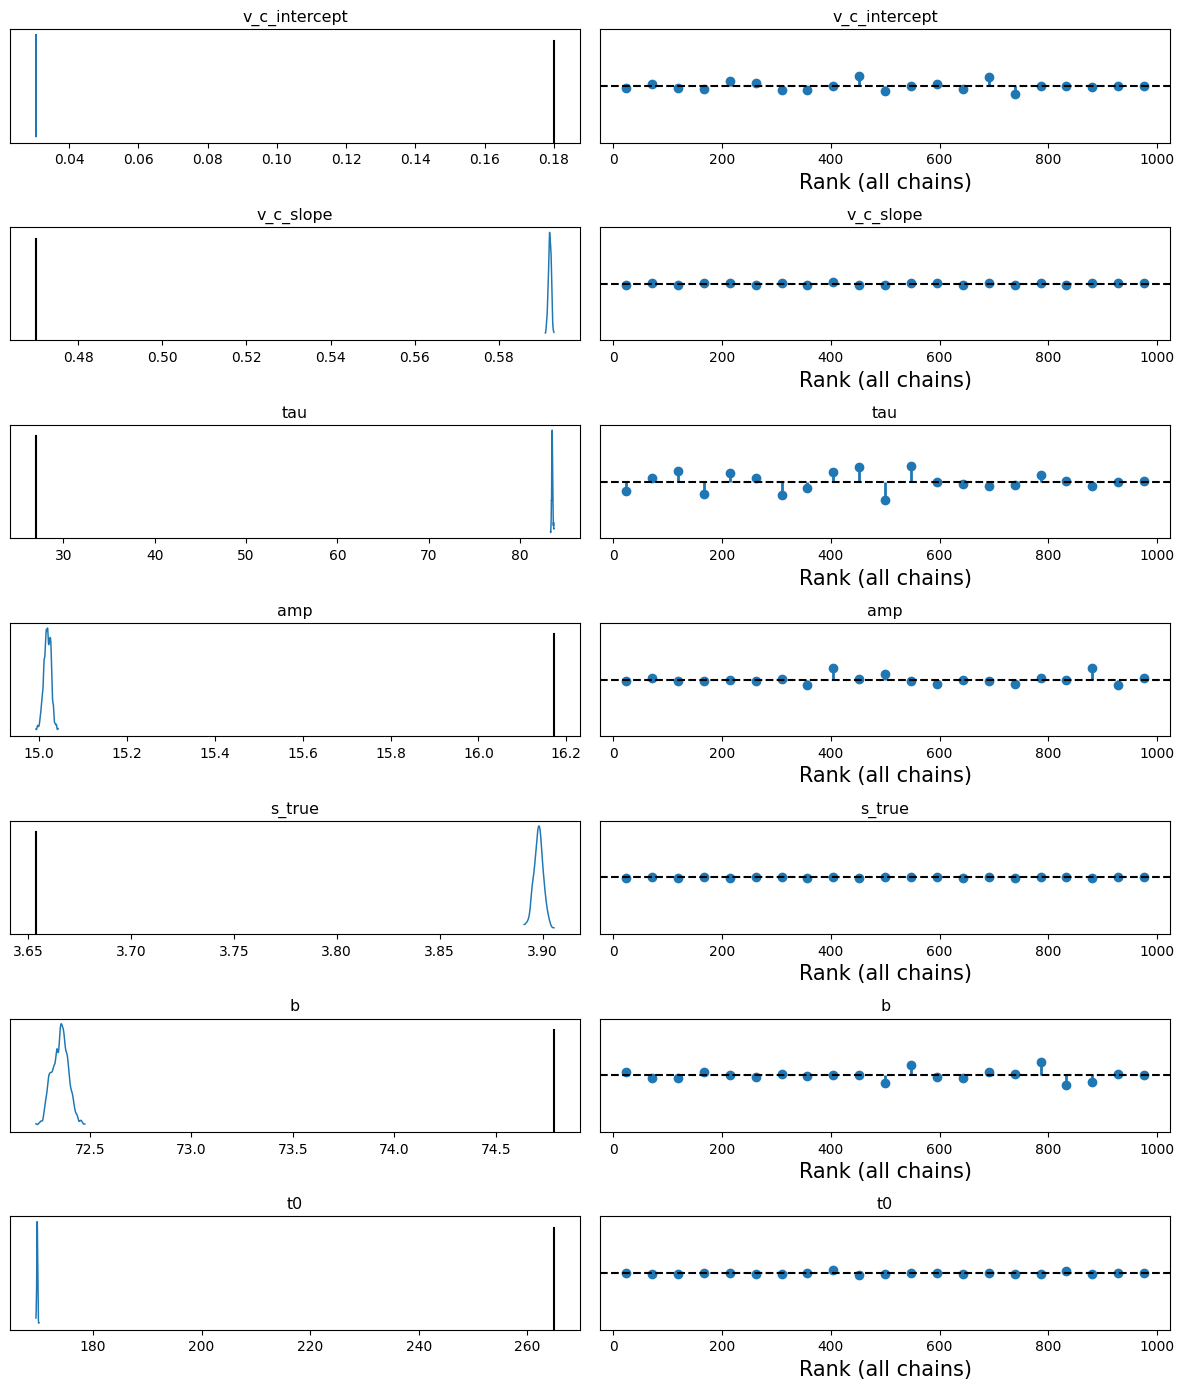

In [29]:
reference_values = {
    key: val for key, val in zip(param_names, prior_draws)
}

idata = az.from_dict(
    posterior={k: v
               for k, v in zip(param_names, np.moveaxis(np.exp(smc_samples.particles), (2, 0, 1), (0, 1, 2)))},)
ax = az.plot_trace(idata, compact=True, kind="rank_vlines")

for i, p in enumerate(prior_draws):
    ax[i, 0].axvline(p, 0, 0.9, color="k")

plt.tight_layout()

In [ ]:
# blackjax.diagnostics.potential_scale_reduction(smc_samples.particles)

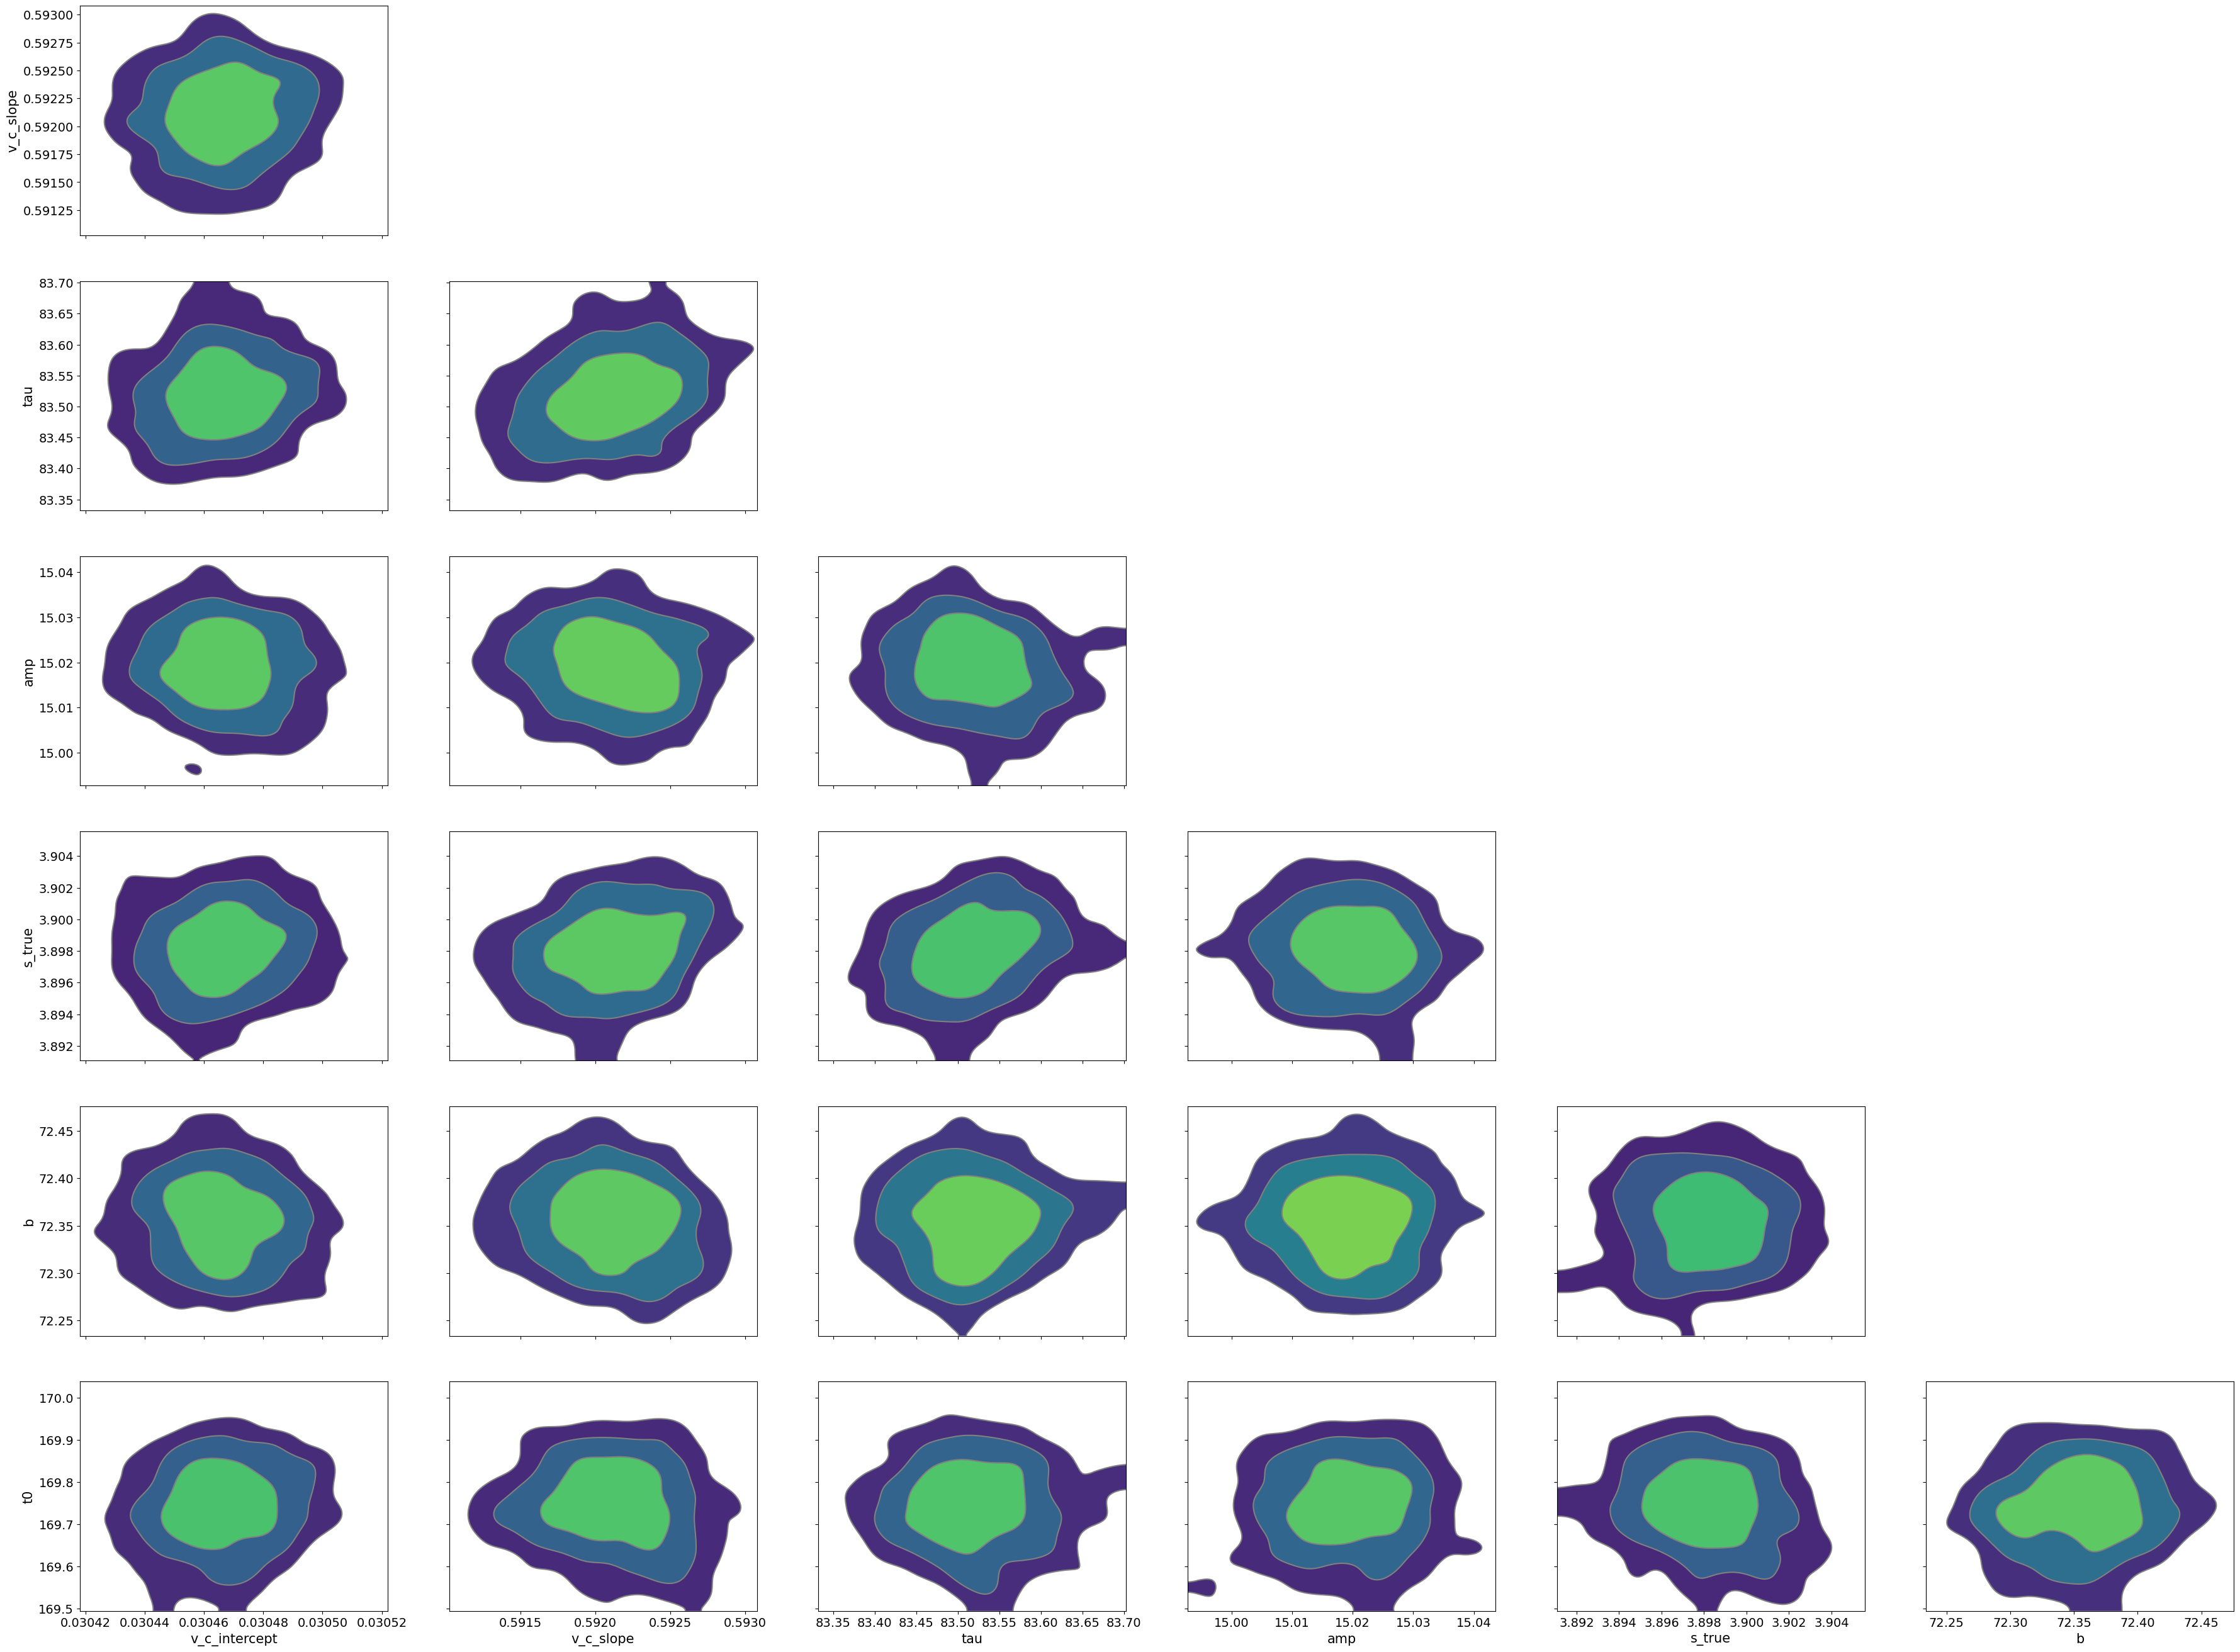

In [30]:
ax = az.plot_pair(idata, kind="kde")